## Sample vs. Population

<b>Population</b>
* A collection of all items of interest
* AKA: parameters
* Denoted by <i>N</i>
* Properly accounting for an entire population is difficult
  * Ex: Studying entire population of a university's student
    * Some students are remote, others part-time, etc.
  * They are hard to observe and contact

<b>Sample</b>
* A subset of the population
* AKA: statistics
* Denoted by <i>n</i> (the number of records within the sample)
  * Ex: Taking a survey of students within a school
    * Each sample (a.k.a. "Replication or Trial"), might have a <i>sample size</i> of 30 students (n = 30)
    * You could then "Replicate" this however many times deemed necessary, and that would be your <i>number of samples</i>
* Less time consuming and costly to gather than a population
  * Easier to observe and contact
* A sample must be both `random` <b>and</b> `representative` for it's insights to be deemed accurate
  * Ex: Going to a restaurant on campus to survey students
  * Randomness
    * A random sample is collected when each member of the sample is chosen from the population strictly by chance
    * This is <b><i>not</i></b> indicative of a random sample since we are excluding all other students not present in the restaurant
  * Representativeness
    * A representative sample is a subset of the population that accurately reflects the members of the entire population
    * This is <b><i>not</i></b> indicative of a representative sample since it represents only NYU students who eat in that specific restaurant
* Interpreted as an approximation of the population parameter

## Fundamentals of Descriptive Statistics

<b>Various Types of Data</b>
* Types of Data
  * Categorical
    * Describes categories or groups
      * Ex: (car brands, yes/no questions, etc.)
  * Numerical
    * Represents numbers, and can further be described into two subsets
    * Discrete
      * Can be counted in a finite matter
        * Ex: The number of children someone has (1, 2, etc.)
      * Opposite of continous data
    * Continuous
      * A number than can take on any value
        * Ex: A person's weight (150.3, 123.56, etc.)

<b>Levels of Measurement</b>
* Qualitative
  * Nominal
    * Are not numbers, and can't be ordered (summer is not a higher rank than winter)
      * Ex: The seasons of the year (autumn, winter, spring, summer)
  * Ordinal
    * Numbers and categories that follow a strict order
      * Ex: Rating your lunch (disgusting, unappetizing, neutral, tasty, delicious)
* Quantitative
  * Represented by numbers
  * Interval
    * Does not have a true 0
      * Ex: Temperature: 40 degrees is not twice as hot as 20 degrees, since 0 degrees is not a true 0
  * Ratio
    * Has a true 0
    * The name comes from the fact that they can represent ratios of things
      * Ex: If I have 2 apples, and someone else has 6; they would have 3 times as many as I do

In [1]:
import numpy as np
import pandas as pd
import random
from datetime import datetime, timedelta

n = 1000  # sample size

# Generate ages first
ages = np.random.randint(18, 70, size=n)

income = 20000 + (ages * 1200) + np.random.normal(0, 8000, size=n)

data = {
    "ID": range(1, n + 1),
    "Age": ages,
    "Gender": np.random.choice(["Male", "Female", "Other"], size=n),
    "Income": np.round(income, 2),
    "Signup_Date": [datetime.today() - timedelta(days=random.randint(0, 365*5)) for _ in range(n)],
    "Subscribed": np.random.choice([True, False], size=n),
    "Department": np.random.choice(["Sales", "Engineering", "HR", "Marketing", "Finance"], size=n),
    "Satisfaction_Score": np.random.randint(1, 11, size=n),  # scale 1-10
    "Comments": np.random.choice([
        "Great service", "Needs improvement", "Very satisfied", "Unhappy", "Okay experience", None
    ], size=n),
    "Bonus_Percentage": np.round(np.random.uniform(0.05, 0.20, size=n), 2)
}

df = pd.DataFrame(data)
print(df.head())


   ID  Age  Gender    Income                Signup_Date  Subscribed  \
0   1   37   Other  62442.09 2022-08-17 17:57:42.786572        True   
1   2   68    Male  89878.57 2023-01-08 17:57:42.786572        True   
2   3   41  Female  76159.35 2020-10-05 17:57:42.786572        True   
3   4   45   Other  86911.05 2023-02-22 17:57:42.786572       False   
4   5   44    Male  71768.12 2025-02-08 17:57:42.786572       False   

  Department  Satisfaction_Score           Comments  Bonus_Percentage  
0  Marketing                   1     Very satisfied              0.10  
1    Finance                   3  Needs improvement              0.06  
2      Sales                   6            Unhappy              0.07  
3      Sales                   4            Unhappy              0.14  
4         HR                   9      Great service              0.09  


In [2]:
#Frequency distribution table, showing number of values for each category
df['Department'].value_counts().sort_values(ascending=False)

Department
Marketing      220
HR             213
Engineering    194
Sales          191
Finance        182
Name: count, dtype: int64

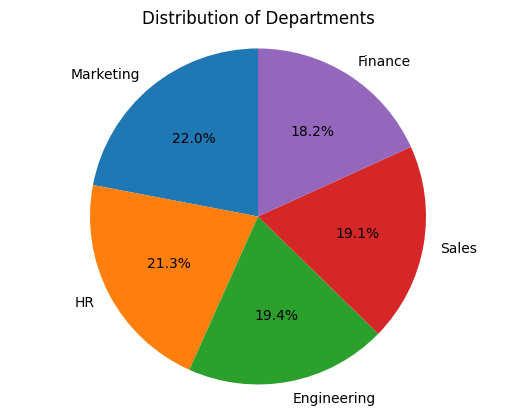

In [3]:
#Relative frequency shows the percentages each category holds in reference to total (totaling to 100%)

import matplotlib.pyplot as plt

# Get counts of each department
dept_counts = df['Department'].value_counts()

# Create the pie chart
plt.pie(
    dept_counts, 
    labels=dept_counts.index, 
    autopct='%1.1f%%', 
    startangle=90
)

plt.title('Distribution of Departments')
plt.axis('equal')  # Equal aspect ratio ensures the pie is a circle
plt.show()

<Axes: xlabel='Income', ylabel='Count'>

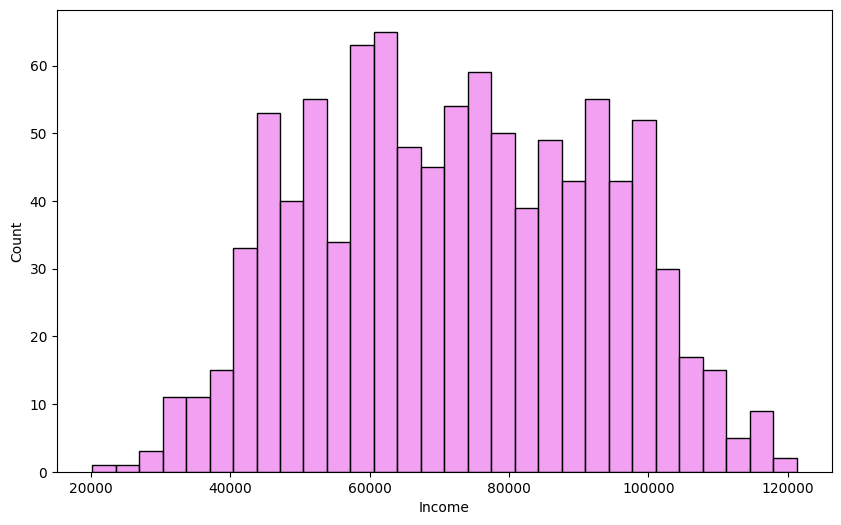

In [4]:
plt.figure(figsize=(10,6))

import seaborn as sns
sns.histplot(data=df, x='Income', bins=30, color='violet', edgecolor='black')

<Axes: xlabel='Age', ylabel='Income'>

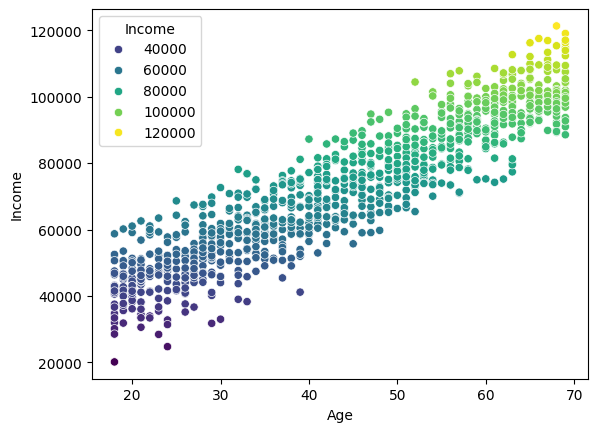

In [5]:
sns.scatterplot(data=df, x='Age', y='Income', hue='Income', palette='viridis')

## Measures of Central Tendency

<b>Mean</b>
* AKA the simple average
* Denoted by greek letter mu (μ) for the population
  * The sample mean is known as x-bar (X̄)
* <b>EASILY affected by outliers</b>

<b>Median</b>
* AKA the middle number in an <i>ordered</i> dataset.
* If you have an even number of observations, take the average of the middle two, and then acquire median from that.

<b>Mode</b>
* The value that appears the most often
* When each value only appears once, we have no mode.

Which measure is best?
* There is no best. It is usually best to utilize them all.

## Measures of Assymmetry

<b>Skewness</b>
* Indicates whether the data concentrates on one side of a distribution
* The direction of the tail indicates the way the skew is "facing".
  * Right-skew has outliers on the right, which is where the tail is. Mean > Median > Mode
  * No-skew is when the Mean = Median = Mode (AKA: Symettrical)
  * Left-skew has outliers on the left, and Mean < Median < Mode<br>
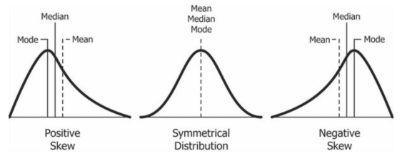

## Measures of Variability

* Variance: Measures the dispersion of a set of data points around their mean (denoted by σ², sigma squared)
* Population variance and sample variance have different formulas
* 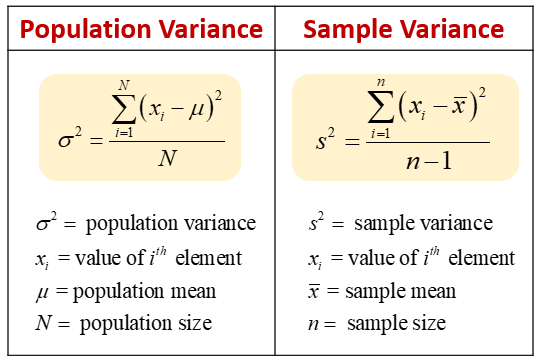
  * Sample variance uses n-1 instead of just n
  * This adjustment (called Bessel’s correction) makes the sample variance an unbiased estimator of the true population variance, since using just n would tend to underestimate the real variability.
* Hard to interpret because the end result unit of measurement is squared

In [6]:
def find_variances(numbers):
    squares = []
    
    nums_mean = sum(numbers) / len(numbers)
    
    for num in numbers:
        squared_result = (num - nums_mean) ** 2
        squares.append(squared_result)

    pop_variance = sum(squares) / len(numbers)
    sampl_variance = sum(squares) / (len(numbers) - 1) #Same as population variance, but our denominator we divide by is (n - 1)

    print(f"Population variance = {pop_variance}")
    print(f"Sample variance = {sampl_variance}")

find_variances([1,2,3,4,5])

Population variance = 2.0
Sample variance = 2.5


## Standard Deviation and Coefficient of Variation

<b>Standard Deviation</b>
<div>
    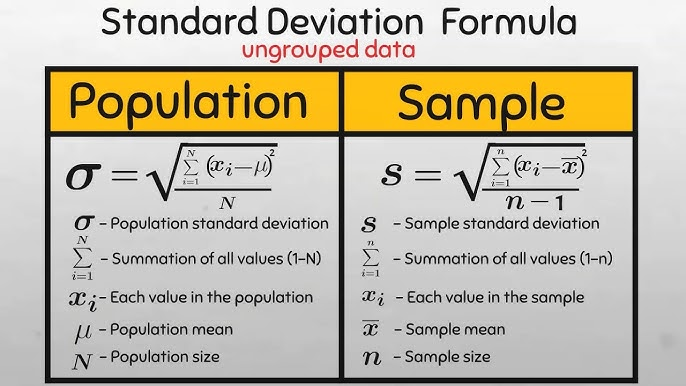
</div>

* Usually more useful in an analyis than the raw variance values, since standard deviation will be easier to interpret
* Measure of variability for a SINGLE dataset
* There is a population and sample standard deviation, similarly to variance
  * These are just the square roots of each one respectively
  * Because we are taking the square root of our variances, the end result puts our values back into an interpretable unit of measurement
  * Ex: So if the average house price is $$350,000 and the std dev is $50,000, people can immediately understand:
    * “Most house prices tend to be within about $50,000 of the average.”
    * Which is much more intuitive than saying the variance is 2.5 × 10,000,000,000 dollars squared.


<br>
<b>Coefficient of Variation</b><br>

* (Standard deviation / mean)
* A.k.a., Relative Standard Deviation
<div>
    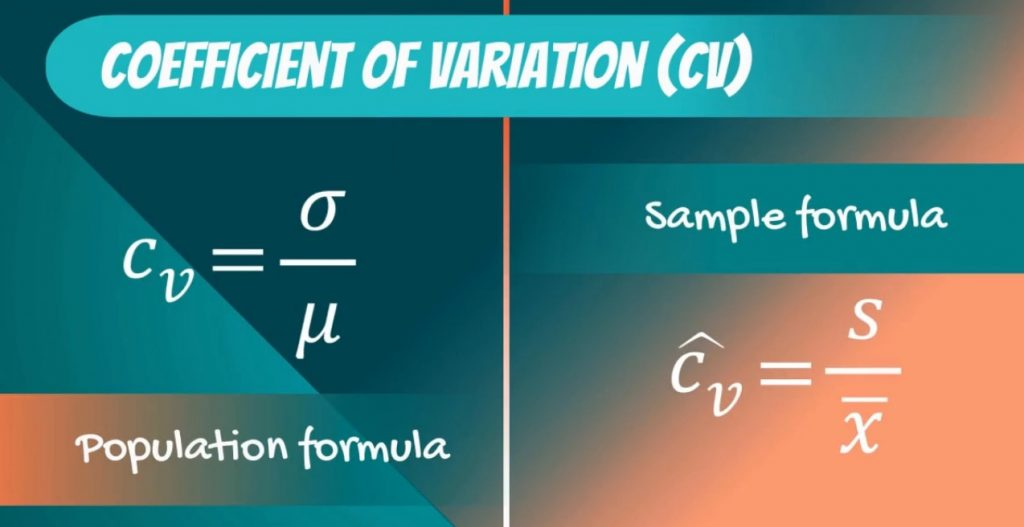
</div>
* Why do we need this?
  * Comparing the std dev of two different datasets is meaningless, and we get around this by using CV.
  * CV normalizes by the mean, canceling out unit scaling, leaving a unitless measure of variability

In [7]:
def summary_stats(numbers):
    squares = []
    
    nums_mean = sum(numbers) / len(numbers)
    
    for num in numbers:
        squared_result = (num - nums_mean) ** 2
        squares.append(squared_result)

    pop_variance = sum(squares) / len(numbers)
    sampl_variance = sum(squares) / (len(numbers) - 1) #Same as population variance, but our denominator we divide by is (n - 1)

    pop_std_dev = np.sqrt(pop_variance)
    sampl_std_dev = np.sqrt(sampl_variance)

    print(f"Mean = {round(nums_mean, 2)}")
    print(f"Population variance = {round(pop_variance, 2)}")
    print(f"Sample variance = {round(sampl_variance, 2)}")
    print(f"Population Std Dev = {round(pop_std_dev, 2)}")
    print(f"Sample Std Dev = {round(sampl_std_dev, 2)}")

summary_stats([1,3,5])

Mean = 3.0
Population variance = 2.67
Sample variance = 4.0
Population Std Dev = 1.63
Sample Std Dev = 2.0


## Calculating and Understanding Covariance

* Understanding how to interprate measures of relationships between several variables

<b>Covariance</b>
<div>
    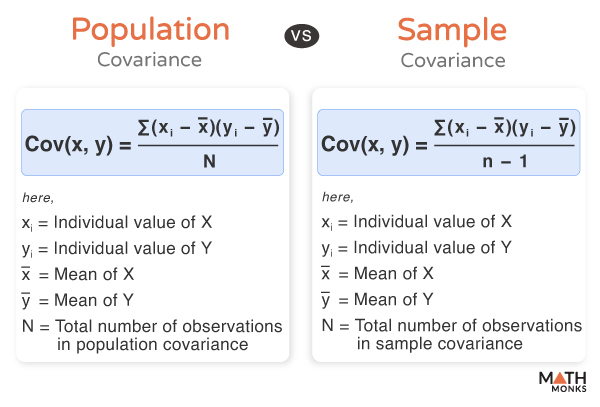
</div>

* Can be >0, =0, <0
  * Depending on our covariance value returned:
    * If >0: the two variables move together
    * If <0: the two variables move in opposite directions
    * If =0: the two variables are independent
  * The covariance between the two variables will always be the same, regardless of variable order
    * Cov(x,y) is the same as Cov(y,x)

In [8]:
# Calculate the covariance between two specific columns
covariance = df['Age'].cov(df['Income'])

print(f"The covariance between Age and Income is: {round(covariance, 2)}")

The covariance between Age and Income is: 284088.38


In [9]:
from statistics import covariance

covariance(df['Age'], df['Income'])

284088.37670926924

<b>Correlation Coefficient</b>
<div>
    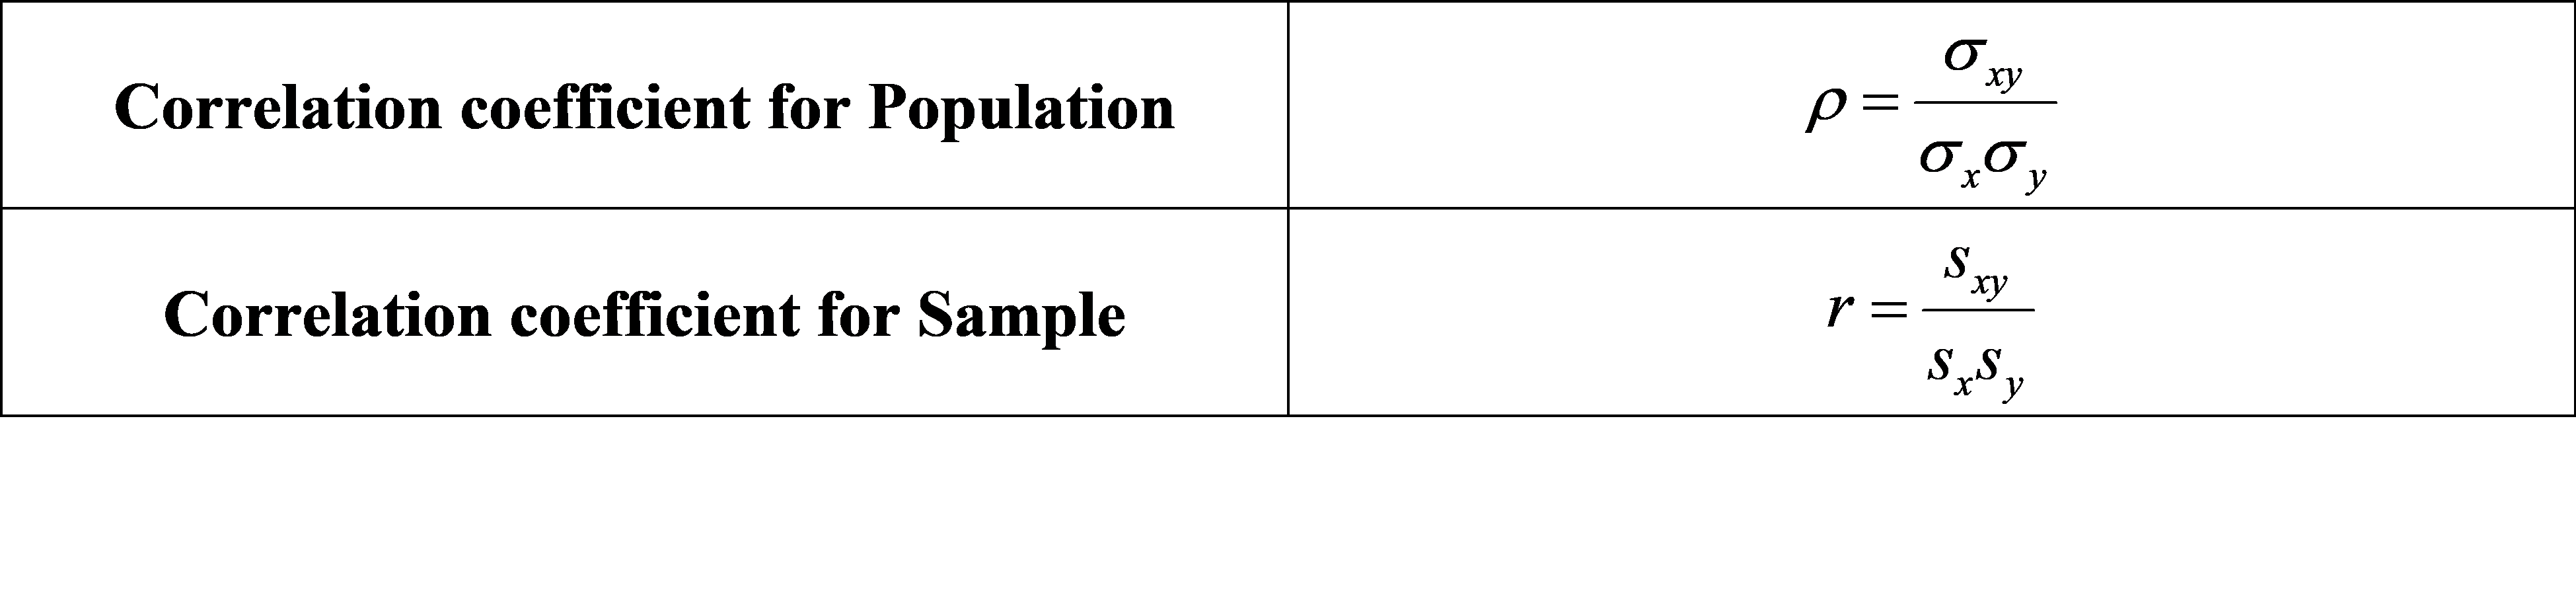
</div>

* Mathematically, there is no way to obtain a value >1 or <-1
  * A correlation of 1 would indicate a perfect/positive correlation
    * To take this explanation a step further, we can say that the entire variability of one variable is explained by the other
    * <i>Ex: A house's size is related to it's price</i>
  * A correlation of 0 would indicate the variables are absolutely independent of each other.
    * <i>Ex: The price of a cup of coffee in Brazil does not affect the price of a house in America</i>
  * A negative correlation coefficient 
    * <i>Ex: Businesses that sell ice cream do well in summer when weather is good, and businesses that sell umbrellas do well when weather is bad. Effectively saying that when one of the companies makes more money, the other will not. </i>
* The direction of causality is important.
  * <i>Ex: House size causes a larger price, and not the other way around</i>
* <b><i>Correlation does not imply causation</i></b>


## Inferential Statistics


<div>
    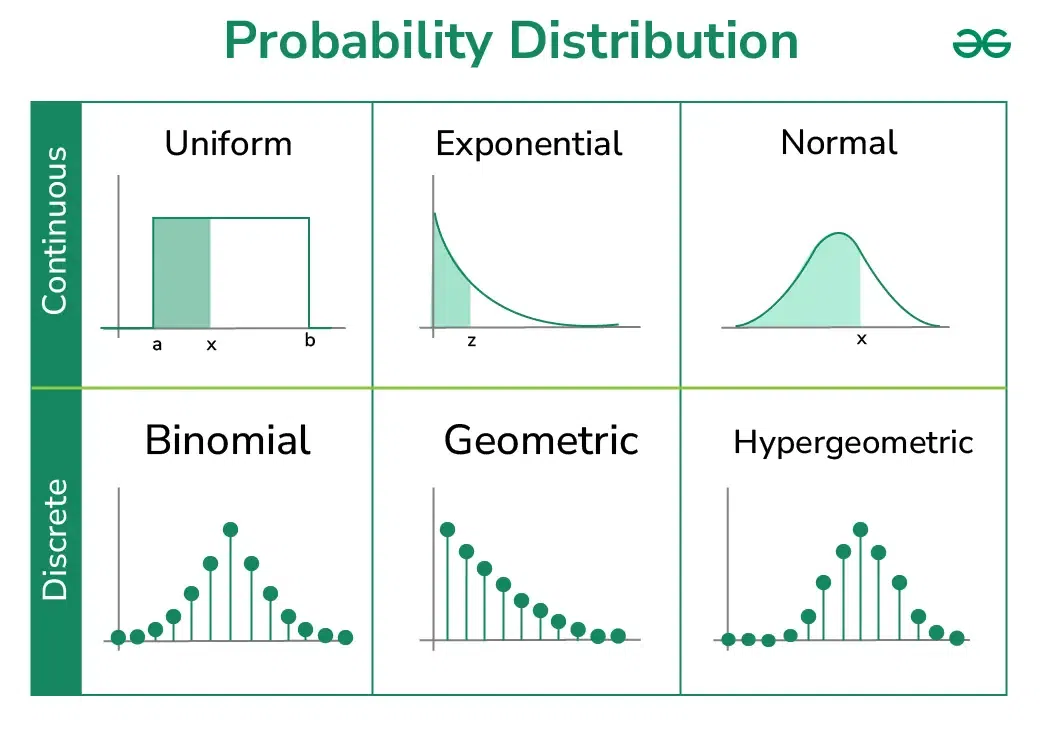
</div>

<b>Distribution</b>
* Usually means a probability distribution
* It is a function that shows the possible values for a variable and how often they occur
  * Ex: Probability of rolling any given number on a di is 1/6. Probability of getting a 7 is 0.
* When sum of probabilities = 1 or 100%, then we have exhausted all possibilities
* Discrete uniform distribution: When all outcomes have an equal chance of occuring
* A distribution is not a graph itself, but rather the probabilities themselves. Graph is just a visual representation.
  * Ex: Calculating probabilities with rolling a pair of dice
    * Probability of getting a total of 1 is zero, because the minimum total is 2.
    * Probability of getting a total of 2 is defined as the total number of combinations that can result in a total of 2 divided by total possible outcomes. In this case, (1/36).

In [14]:
#Given a user inputted number, calculate the odds of rolling two dice and receiving a sum of the two dice which equal the user number
def calculate_dice_odds(total_prompt):
    try:
        total_prompt = int(total_prompt)  # ensure it's an integer
    except ValueError:
        raise ValueError("total_prompt must be a number")
        
    combinations_total = 0
    
    dice_1 = range(1, 7)
    dice_2 = range(1, 7)

    max_num_combinations = (max(dice_1) * max(dice_2))

    for a in dice_1:
        for b in dice_2:
            if a + b == total_prompt:
                combinations_total += 1
                    
    return (f"Odds of getting a total of {total_prompt}: {round((combinations_total / max_num_combinations)  * 100, 2)}%")

In [20]:
calculate_dice_odds(4)

'Odds of getting a total of 4: 8.33%'

In [12]:
#Explanation: 
# Get each unique total combination between the two sets of dice.
# Take that total, and give it a matching value of 0 if no value is returned, otherwise add 1 (this is tracking the total number of outcomes for that specific total)
def calculate_all_dice_odds():
    dice_1 = range(1, 7)
    dice_2 = range(1, 7)
    
    max_num_combinations = len(dice_1) * len(dice_2)

    # Dictionary to store frequency of each total
    totals = {}

    # Single pass over all dice rolls
    for a in dice_1:
        for b in dice_2:
            total = a + b
            totals[total] = totals.get(total, 0) + 1  # increment count

    # Print results
    print("Total | Odds:")
    for n in range(2, 13):  # sums go from 2 to 12
        odds = round((totals[n] / max_num_combinations) * 100, 2)
        print(f"{n:>5} | {odds:>5}%")

    #Graph Results
    totals_keys = list(totals.keys())
    totals_values = list(totals.values())

    probabilities = [v / max_num_combinations for v in totals_values]
    
    plt.bar(totals_keys, probabilities, color='lightgreen')
    plt.xlabel('Dice Total')
    plt.ylabel('Probability')
    plt.title('Probability Distribution of Dice Totals')
    plt.xticks(totals_keys)
    plt.show()

Total | Odds:
    2 |  2.78%
    3 |  5.56%
    4 |  8.33%
    5 | 11.11%
    6 | 13.89%
    7 | 16.67%
    8 | 13.89%
    9 | 11.11%
   10 |  8.33%
   11 |  5.56%
   12 |  2.78%


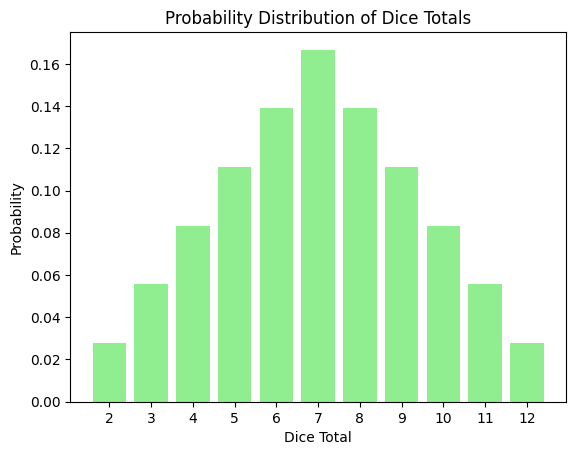

In [13]:
calculate_all_dice_odds()

<b>Normal Distribution & Student's T Distribution</b>
* Approximates a wide variety of random variables, but not all random variables follow this
* Distributions of sample means with large enough sample sizes could be approximated to normal
* All computable statistics are elegant
  * These are called “computable” because you can write down a formula and calculate them numerically
  * Elegant here refers to nice mathematical properties:
    * Closed-form formulas
    * Exact or known distributions
    * Useful inference properties (like unbiasedness, consistency)
  * Essentially, a statistic is “elegant” if it’s mathematically neat, interpretable, and practical.
* Decisions based on normal distribution insights have a good track record

<b>Normal Distribution</b>
* A.k.a.: Gaussian distribution, or Bell Curve
* Symmetrical, and mean = median = mode
* No skew, perfectly centered around it's mean
* Controlling for the standard deviation (keeping it the same, with a changing mean)
  * A lower or higher mean would result in the same distribution, but moving it left or right respectively
* Controlling for the mean (keeping it the same, but adjusting standard deviation)
  * Graph does not move, but reshapes
    * A higher standard deviation results in a higher dispersion of the data
      * Less data in the middle, and "fatter" tails (more data in the tails)
    * A lower standard deviation results in a lower dispersion of the data
      * More data in the middle, and "thinner" tails (less data in the tails)

<b>Standardization</b>
* Every distribution can be standardized
* Standardization is the process of taking (mu (μ) represents the population mean, and sigma squared (σ²) represents the population variance) and transforming it to 1, with a mean of 0 and a std dev of 1
  * z = (x - μ) / σ
    * z is z-score, which is the standardized variable
    * x being the original variable, subtract it's mean, and divide that by the standard deviation
  * When we standardize a normal distribution, the result is a standard normal distribution

<b>Central Limit Theorum</b>
* Drawing conclusions from a single sample is suboptimal, given that each sample will likely produce different results from the last
* A distribution formed by samples is called a `sampling distribution`
  * Could take this even further and say "sampling distribution of the mean", depending on your metric being evaluated
* We can take many different sample means from the population, and we can say that the overall mean of the sample means is an approximation of the population mean itself.
* No matter the distribution of the population, the `sampling distribution of the mean` will approximate a normal distribution
  * Sample mean will also approximate that of the population mean
  * Variance of the samples depends on the size of the samples we draw, but it can be found by using the (population variance / sample size)
    * In other words, the bigger the samples we can utilize, the more accurate our results will be
* For the CLT to apply, we need a sample size of at least 30 observations
  * When someone says “you need 30 observations for the CLT,” what they really mean is:
    * You need a sample size of about 30 in each sample you draw from the population.
  * So, if you have a population (say 10,000 people), you would:
    * Draw a random sample of 𝑛 = 30 (30 people)
    * Compute the mean of that sample
    * Repeat this many times (in theory), building up the distribution of sample means.
    * That distribution of means is what becomes approximately normal thanks to the CLT.
  * It does not mean you only pull 30 records from the population one time and you’re done.
  * A single sample of 30 observations is just one instance; the CLT is about the behavior of the sampling distribution if you repeated this over and over.

<b>Standard Error</b>
* The standard deviation of the distribution formed by the sample means
  * In other words, it is the standard deviation of the sampling distribution
  * How to find this? We know it's variance: (σ² / n), so we can get the std dev of this by taking the square root of (σ² / n)
* Similarly to standard deviation, the standard error shows variability
  * In this case, it is the variability of the different means of the samples we have extracted
* Shows how well we have approximated the true mean
  * The standard error decreases as the sample size increases.
  * This is because bigger samples give a better approximation of the population
    * Effectively, more samples = more ability to cancel out "noise"
    * The `Law of Large Numbers` is what is applying here.
      * As the sample size grows, the sample average gets closer and closer to the true population average
  * Remember that the variance of the sample mean equals: (σ² / n)
    * So the more data points we have within each sample leads to a lower variance since we are dividing by <i>n</i>

## Estimators and Estimates

<b>Estimator</b>
* The actual function you use to calculate an estimate
* Always looking for the most efficient, and unbiased estimators
  * An unbiased estimator has an expected value = population parameter
    * Ex: X-bar is expected to be equal to mu

<b>Estimate</b>
* The number you get as a result of your estimator function
* Point Estimate:
  * A single number
  * Located in the middle of the confidence interval
  * Ex: Population mean (mu, our parameter) has an estimator (X-bar, the sample mean), and our estimate is the numerical value of our estimator function (the true value of the sample mean)
* Confidence Interval:
  * An interval between two numbers
 
<b>Bias</b>
* Bias is the difference between the expected value of an estimator and the true population parameter
* In other words, bias tells you whether, on average across many samples, your estimator hits the true value or systematically misses it

<b>Efficiency</b>
* Efficiency compares the variability (variance) of different unbiased estimators of the same parameter.
* A more efficient estimator has a smaller variance.

<b>Confidence Intervals</b>
* The range within which you expect the population parameter to be.
* Point estimates give us a greater idea of the overall population, but confidence intervals are much safer
* Can never truly be 100% confident in our results
* A 95% CI means there is only a 5% chance that the population parameter is outside the range
* Confidence Level
  * Denoted by 1-alpha (α)
  * Called the confidence level of the interval
  * A value between 0 and 1
  * Ex: If we want to be 95% confident our value is within the interval, our alpha(α) is 5%
* Formula: `[Point Estimate - Reliability Factor * Standard Error, Point Estimate + Reliability Factor * Standard Error]`
* Can be two main situations when we calculate the CI for our population (calculation method depends on which)
  * Known variance
    * Important assumption: The population is normally distributed
      * Even if it isn't, use a large sample and let the CLT kick in to help with normalization
    * 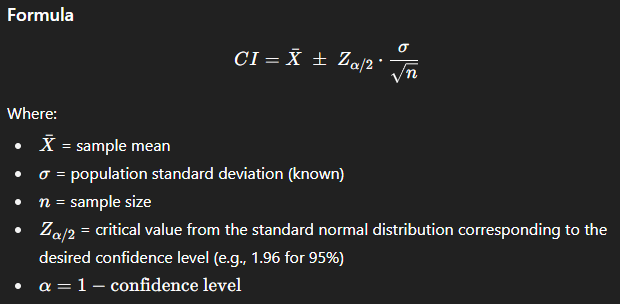
    * A commonly used term for the Z is the `critical value`
    * Using the Z-table (ex. with a 95% CI):
      * alpha(α) is 5%, or `0.05`
      * We then need Z of alpha/2 (0.05/2 = `0.025`)
      * In the table, this will match `1 - 0.025 = 0.975`
      * We then find `0.975` on our z-table, and sum the column/row headers together.
        * In this case, they are `1.9 + 0.06 = 1.96`
    * 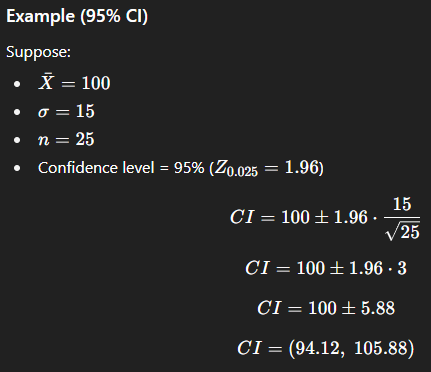
    * Interpretation of the CI: "We can be 95% confident that the true average value of our metric is between about 94 and 106 minutes."
    * When using CI/CL values that don't have a specific end result z value, we round to the nearest available value in the z-table and continue the calculation like we normally would from there.
    * There is a trade-off between the CL (95% vs. 99%) and the resulting range of values we get.
      * Ex: If we are studying salaries, with a `95% CL we might get a CI of [$94,833, $105,568]` but we then increase our CL to 99% we might see a broader range of values but with a higher level of confidence/certainty in the amounts: `99% CL we might get a CI of [$93,135, $107,206]`
  * Unknown variance

In [ ]:
def 